In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sqlite3

conn = sqlite3.connect('../../data/db/bluestock_mf.db')

nav = pd.read_sql("SELECT * FROM fact_nav", conn)
perf = pd.read_sql("SELECT * FROM fact_performance", conn)
tx = pd.read_sql("SELECT * FROM fact_transactions", conn)
fund = pd.read_sql("SELECT * FROM dim_fund", conn)

nav['date'] = pd.to_datetime(nav['date'])
tx['transaction_date'] = pd.to_datetime(tx['transaction_date'])

In [2]:
aum = pd.read_csv('../../data/raw/03_aum_by_fund_house.csv')
sip = pd.read_csv('../../data/raw/04_monthly_sip_inflows.csv')
category = pd.read_csv('../../data/raw/05_category_inflows.csv')
folio = pd.read_csv('../../data/raw/06_industry_folio_count.csv')
holdings = pd.read_csv('../../data/raw/09_portfolio_holdings.csv')

In [3]:
print("aum:", aum.columns.tolist())
print("sip:", sip.columns.tolist())
print("category:", category.columns.tolist())
print("folio:", folio.columns.tolist())
print("holdings:", holdings.columns.tolist())

aum: ['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
sip: ['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']
category: ['month', 'category', 'net_inflow_crore']
folio: ['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
holdings: ['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


## *NAV trend analysis* - *Plotly Line Chart*

In [ ]:
fig = px.line(nav, x='date', y='nav', color='amfi_code',
              title='NAV Trend — All 40 Schemes (2022–2026)')
fig.add_vrect(x0="2023-01-01", x1="2023-12-31", fillcolor="green", opacity=0.1,
              annotation_text="2023 Bull Run")
fig.add_vrect(x0="2024-01-01", x1="2024-12-31", fillcolor="red", opacity=0.1,
              annotation_text="2024 Correction")
fig.write_image("nav_trend.png")
fig.show()

## *AUM growth - bar chart*

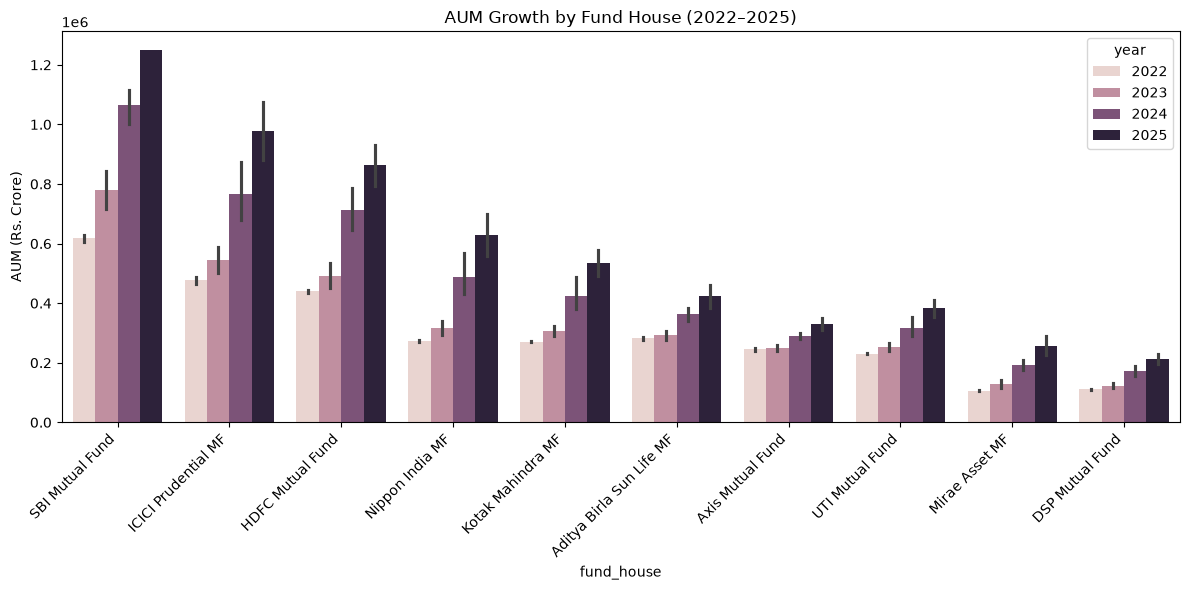

In [5]:
aum['date'] = pd.to_datetime(aum['date'])
aum['year'] = aum['date'].dt.year

plt.figure(figsize=(12,6))
sns.barplot(data=aum, x='fund_house', y='aum_crore', hue='year')
plt.xticks(rotation=45, ha='right')
plt.title('AUM Growth by Fund House (2022–2025)')
plt.ylabel('AUM (Rs. Crore)')
plt.tight_layout()
plt.savefig('aum_growth.png')
plt.show()

## *SIP inflow time-series - Plotly Line Chart*

In [ ]:
sip['month'] = pd.to_datetime(sip['month'], format='%Y-%m')

fig = px.line(sip, x='month', y='sip_inflow_crore', title='Monthly SIP Inflow (2022–2025)')

peak = sip.loc[sip['sip_inflow_crore'].idxmax()]

fig.add_annotation(
    x=peak['month'].strftime('%Y-%m-%d'),   #convert Timestamp to string
    y=peak['sip_inflow_crore'],
    text=f"All-Time High: ₹{peak['sip_inflow_crore']:,} Cr",
    showarrow=True, arrowhead=2
)
fig.show()
fig.write_image("sip_trend.png")

## *Category inflow - heatmap*

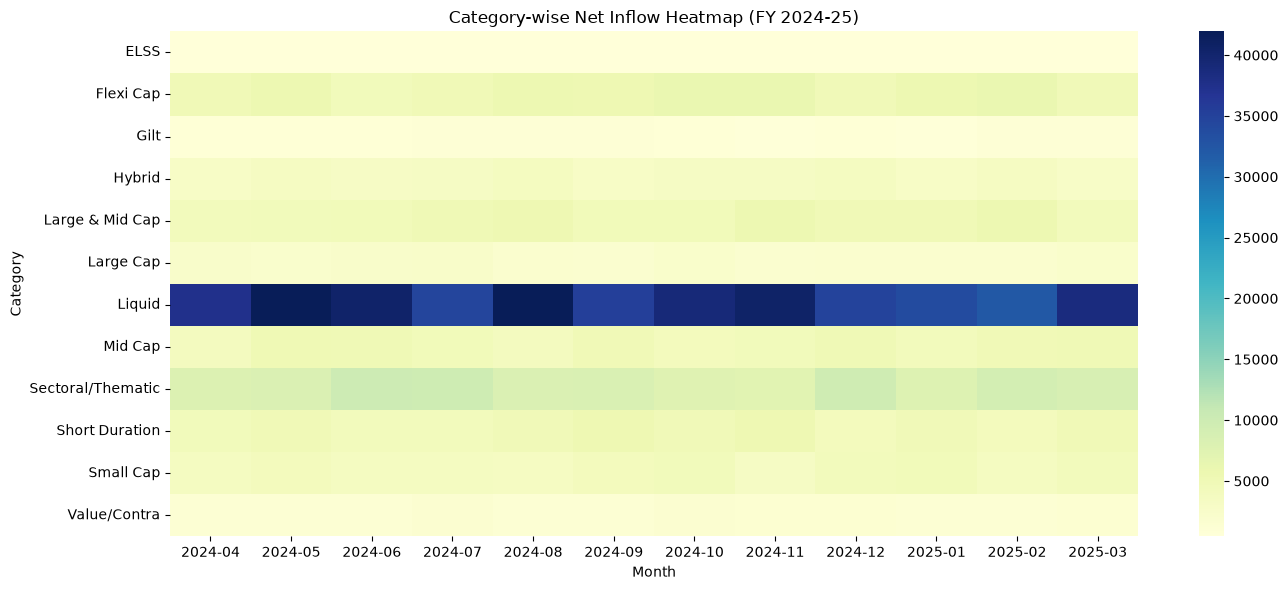

In [11]:
pivot = category.pivot_table(index='category', columns='month', values='net_inflow_crore')

plt.figure(figsize=(14,6))
sns.heatmap(pivot, cmap='YlGnBu', annot=False)
plt.title('Category-wise Net Inflow Heatmap (FY 2024-25)')
plt.xlabel('Month')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('category_heatmap.png')
plt.show()

## *Investor demographics*

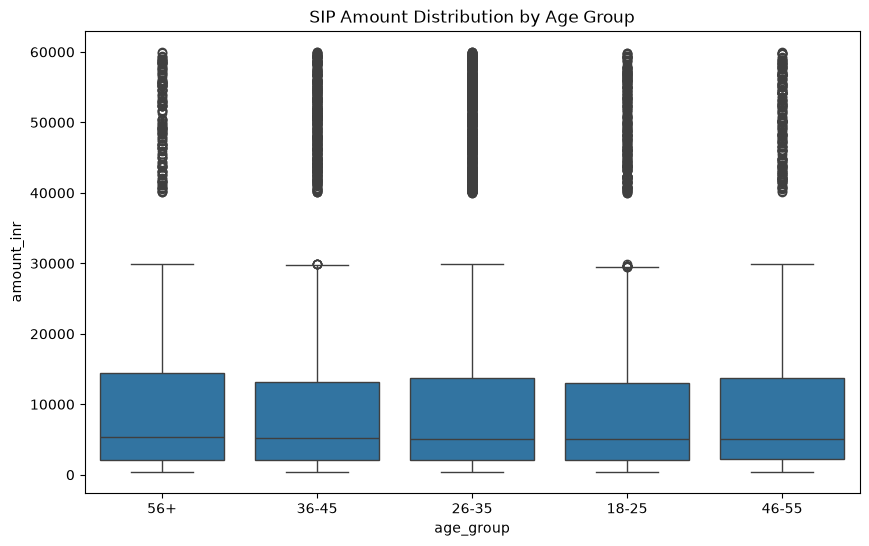

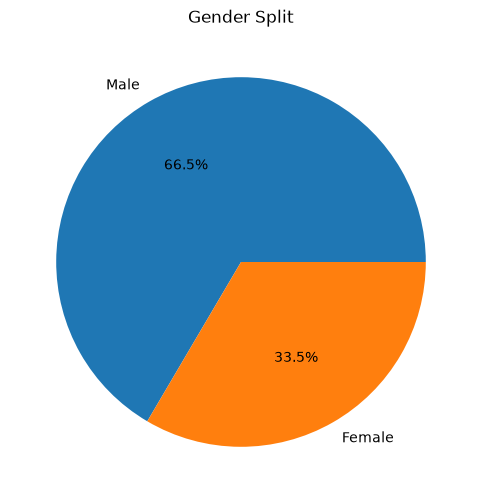

In [ ]:
# Age group distribution - box plot
sip_tx = tx[tx['transaction_type'] == 'Sip']
plt.figure(figsize=(10,6))
sns.boxplot(data=sip_tx, x='age_group', y='amount_inr')
plt.title('SIP Amount Distribution by Age Group')
plt.savefig('sip_by_age.png')
plt.show()

# Gender split (SIP amount box plot by age group) - Pie Chart
plt.figure(figsize=(6,6))
tx['gender'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Gender Split')
plt.savefig('gender_split.png')
plt.show()

## *Geographic distribution*

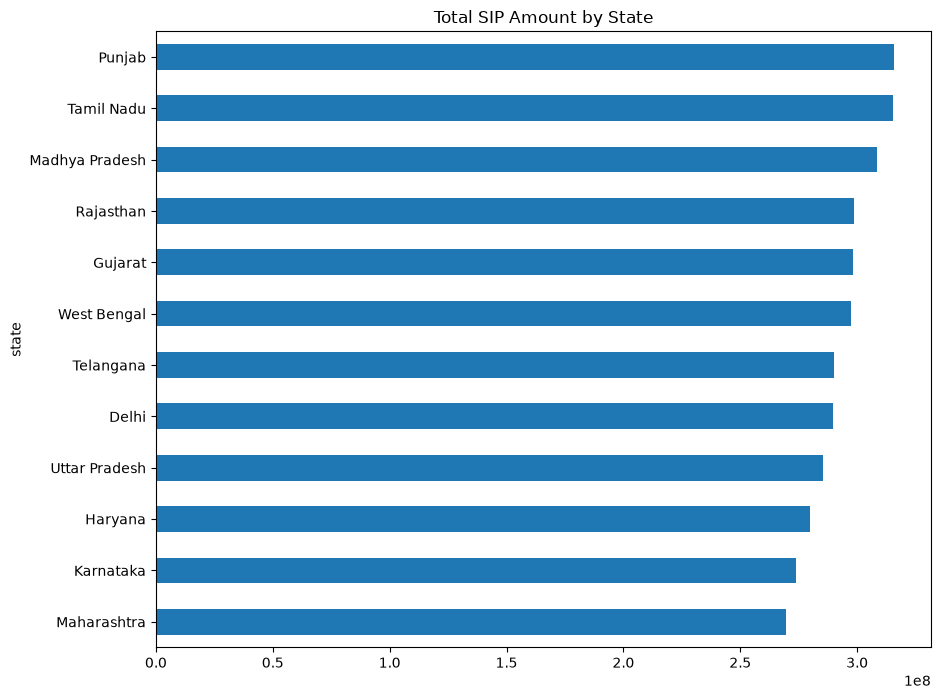

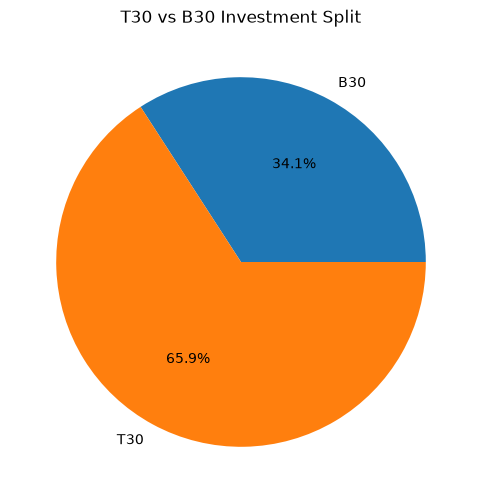

In [13]:
# Horizontal bar chart of SIP amount by state
state_totals = tx.groupby('state')['amount_inr'].sum().sort_values()
plt.figure(figsize=(10,8))
state_totals.plot.barh()
plt.title('Total SIP Amount by State')
plt.savefig('state_distribution.png')
plt.show()

#T30 vs B30 city tier pie chart
tier_totals = tx.groupby('city_tier')['amount_inr'].sum()
plt.figure(figsize=(6,6))
tier_totals.plot.pie(autopct='%1.1f%%')
plt.title('T30 vs B30 Investment Split')
plt.savefig('city_tier_split.png')
plt.show()

## *Folio count growth - line chart*

In [15]:
folio['month'] = pd.to_datetime(folio['month'], format='%Y-%m')

fig = px.line(folio, x='month', y='total_folios_crore',
              title='Total MF Folio Growth (13.26 Cr → 26.12 Cr)')
fig.write_image("folio_growth.png")
fig.show()

## *NAV return correlation matrix - Seaborn heatmap*

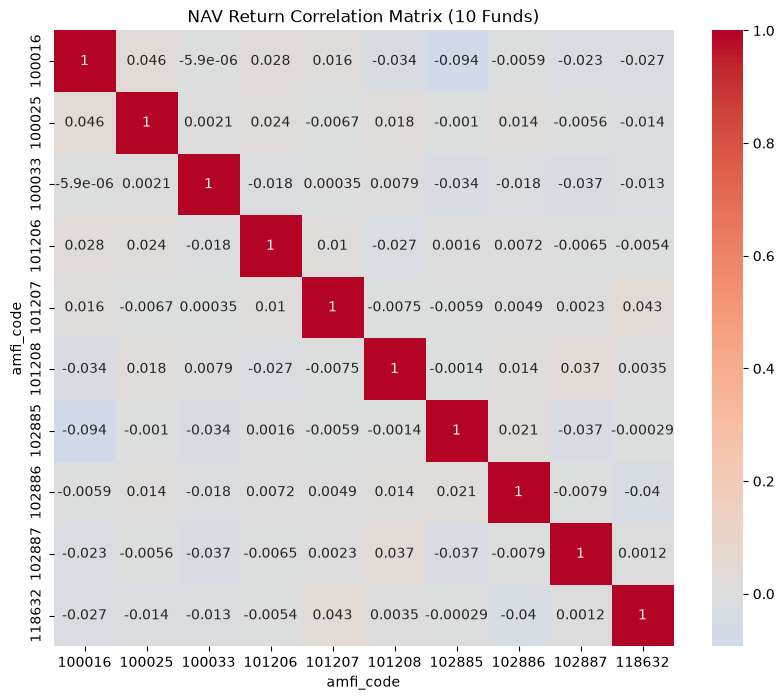

In [16]:
top10 = nav['amfi_code'].unique()[:10]
nav_wide = nav[nav['amfi_code'].isin(top10)].pivot(index='date', columns='amfi_code', values='nav')
returns = nav_wide.pct_change().dropna()

plt.figure(figsize=(10,8))
sns.heatmap(returns.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('NAV Return Correlation Matrix (10 Funds)')
plt.savefig('correlation_matrix.png')
plt.show()

## *Sector allocation - donut chart*

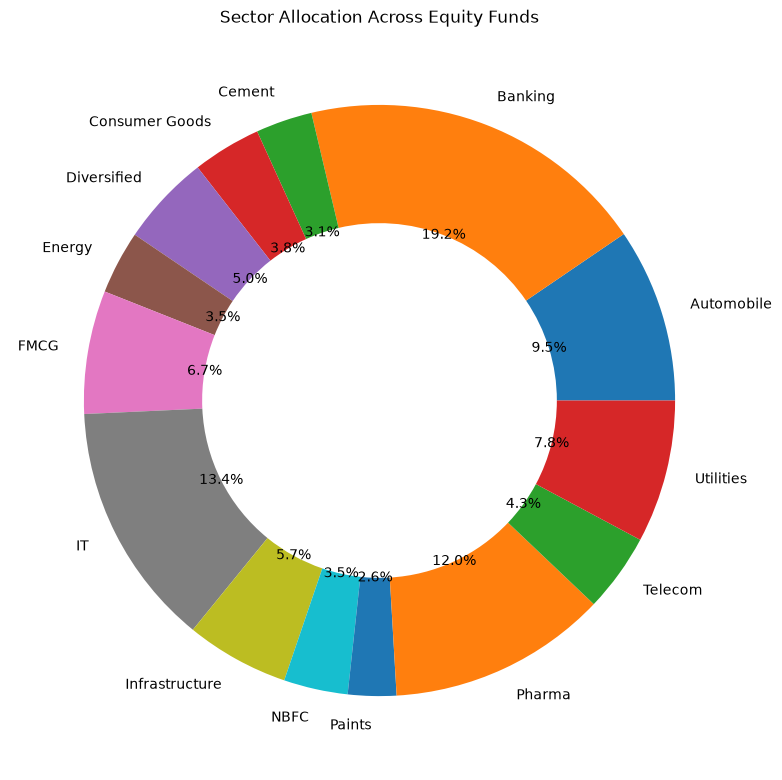

In [17]:
sector_weights = holdings.groupby('sector')['weight_pct'].sum()

plt.figure(figsize=(8,8))
plt.pie(sector_weights, labels=sector_weights.index, autopct='%1.1f%%',
        wedgeprops=dict(width=0.4))
plt.title('Sector Allocation Across Equity Funds')
plt.tight_layout()
plt.savefig('sector_allocation.png')
plt.show()